# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [3]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
import datetime as dt
import scipy.stats as st

from sklearn import model_selection, metrics, preprocessing


import matplotlib.pyplot as plt
import seaborn as sns

cm = 1./2.54

## Paramètres graphiques et fonctions utiles

In [4]:
import subprocess

white_font = True
def set_theme( white_font=True ):
    """ set_theme( white_font=True ) """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme( 'notebook' , rc=rc )
    return


def make_folder( path_folder ):
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir( path_folder ) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return

def concat_folders(*args, **kwargs):
    """ concat_folders(*args, **kwargs)
        concatenate folders in args (strings) """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath

class Path(object):
    """ Path( s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """docstring."""
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index( s_lim ) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir( self ):
        return make_folder( self )


def gs_opt( filename ):
    """ otpimisation of a pdf file with gosthscript """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run( 'rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run( 'mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file

def savefig( fig, savename, **kwargs ):
    """ savefig( fig, savename, **kwargs )
        Saves a figure with kwargs (fig.savefig( savename, **kwargs) ).
        A check is done first to determine if a folder has to be created according to savename.
        Finally, if the file is saved as .pdf, gosthscript optimisation is performed. """
    if os.sep in savename: make_folder( savename[:savename.rindex(os.sep)] )
    fig.savefig( savename, **kwargs )
    savename += '.pdf'
    if os.path.isfile( savename ): gs_opt( savename )


def image_size_from_width_and_shape( width: float, shape: tuple, ymargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return width, width*shape[0]/shape[1]+ymargin

def image_size_from_height_and_shape( height: float, shape: tuple, xmargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return height*shape[1]/shape[0]+xmargin, height


set_theme()
del set_theme

## Chargement des données

(-3.295982292522653,
 3.3358242949517383,
 -3.296666169432208,
 3.3515288407460146)

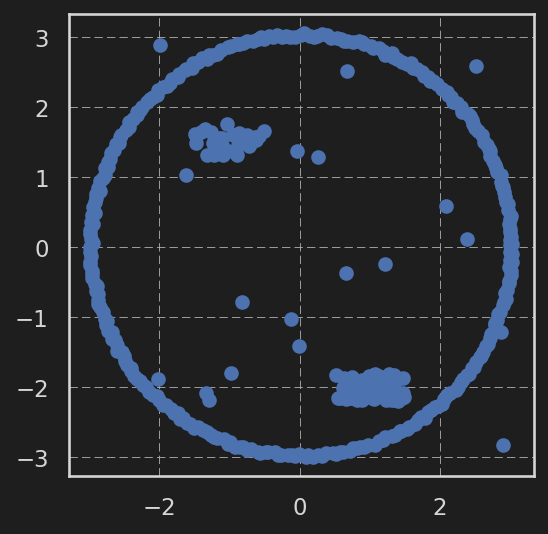

In [16]:
tta = np.linspace( 0, 2*np.pi, 300 )
R = 3.
noise = 0.05
x1, y1 = R * np.cos( tta ), R * np.sin(tta)
x1 += np.random.rand(x1.size)*noise
y1 += np.random.rand(x1.size)*noise

def create_blob( n, wx, wy, x0, y0 ):
    return (np.random.rand(n)-0.5)*(2*wx) + x0, (np.random.rand(n)-0.5)*(2*wy) + y0

n = 30
x2, y2 = create_blob( n, 0.5, 0.2, -1, 1.5 )

n = 70
x3, y3 = create_blob( n, 0.5, 0.2, 1, -2 )

n = 20
xn, yn = (np.random.rand( n )-0.5) * (2*3), (np.random.rand( n )-0.5) * (2*3)

x = np.concatenate( (x1,x2,x3, xn) )
y = np.concatenate( (y1,y2,y3, yn) )

fig, ax = plt.subplots( figsize=(4,4) )
ax.plot( x, y, 'o' )
ax.axis('equal')

(420, 2)
xy min: [-1.6459007  -1.36657617]
xy max: [1.52868729 1.60361771]
labels min: -1
labels max: 2
n labels: 3


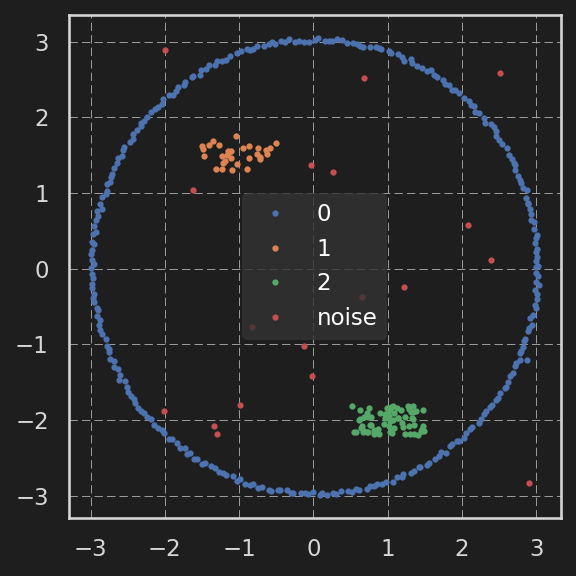

In [71]:
def voisinage( x, X, eps ):
    return ((X - x.reshape(1,-1) )**2).sum(1) <= eps

class DBSCAN_Cluster:
    def __init__( self, eps, nlim ):
        self.eps = eps
        self.nlim = nlim
        self.C = []
        return

    def get_n_labels( self ):
        return len(self.C)

    def fit_transform( self, X ):
        indices = np.arange( X.shape[0] )
        labels = np.full( indices.size, -2 )
        eps = self.eps**2
        nlim = self.nlim
        self.X = X.copy()

        for i, x in enumerate( X ):
            if labels[i] > -2: # le point a déjà été visité
                continue
            Cp = voisinage( x, X, eps )
            N_close = Cp.sum()
            # print(i, N_close)
            close_labels = np.unique( labels[Cp] )
            close_labels = close_labels[ close_labels > -1]
            if len(close_labels) == 0:
                if N_close < nlim: # noise point
                    labels[i] = -1
                    continue
                # new cluster
                labels[Cp] = len( self.C )
                self.C.append( Cp )
                continue
            # concatenate clusters
            imin = close_labels.min()
            # print('close_labels:', close_labels)
            # print('imin:', imin)
            for j in close_labels[-1::-1]:
                Cp = Cp | self.C[j]
                if j == imin :
                    continue
                self.C.pop( j )
            self.C[imin] = Cp
            labels[Cp] = imin
        return labels

X = np.vstack( (x,y) ).T
print(X.shape)
scaler = preprocessing.StandardScaler().fit( X )
X_scaled = scaler.transform( X )

print('xy min:', X_scaled.min(0))
print('xy max:', X_scaled.max(0))

eps = 0.1
nlim = 3

clusters = DBSCAN_Cluster( eps, nlim )
labels = clusters.fit_transform( X_scaled )

print( 'labels min:', labels.min() )
print( 'labels max:', labels.max() )
print('n labels:', clusters.get_n_labels())

fig, ax = plt.subplots( figsize=(4,4))
for i in range( clusters.get_n_labels() ):
    inds = labels == i
    ax.plot( x[inds], y[inds], 'o', markersize=2, label=i )



inds = labels == -1
ax.plot( x[inds], y[inds], 'o', markersize=2, label='noise' )
# ax.plot( X_scaled[inds,0], X_scaled[inds,1], 'o', label='noise' )

ax.legend()



fig.tight_layout()


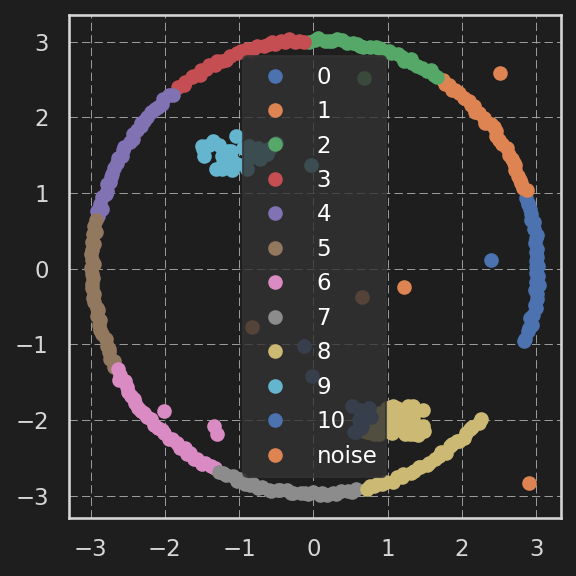